In [1]:
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "Data"

print(f"Using device: {device}")
print(f"Dataset folder exists: {DATA_DIR.exists()}")

Using device: cpu
Dataset folder exists: True


In [3]:
scan_records = []

for class_name, label in [("Hemorrhagic", 1), ("NORMAL", 0)]:
    class_dir = DATA_DIR / class_name

    for folder in class_dir.rglob("*"):
        if folder.is_dir() and any(folder.glob("*.jpg")):
            scan_records.append(
                {
                    "scan_id": str(folder.relative_to(DATA_DIR)),
                    "class_name": class_name,
                    "label": label,
                    "slice_count": len(list(folder.glob("*.jpg"))),
                }
            )

scans_df = pd.DataFrame(scan_records)

print(f"Total scans found: {len(scans_df)}")
scans_df["class_name"].value_counts()

Total scans found: 45


class_name
NORMAL         27
Hemorrhagic    18
Name: count, dtype: int64

In [4]:
excluded_scan_id = r"NORMAL\N27[N27]"

scans_df_clean = (
    scans_df[scans_df["scan_id"] != excluded_scan_id]
    .copy()
    .reset_index(drop=True)
)

print(f"Scans used for CNN–LSTM: {len(scans_df_clean)}")
scans_df_clean["class_name"].value_counts()

Scans used for CNN–LSTM: 44


class_name
NORMAL         26
Hemorrhagic    18
Name: count, dtype: int64

In [5]:
train_val_scans, test_scans = train_test_split(
    scans_df_clean,
    test_size=0.20,
    stratify=scans_df_clean["label"],
    random_state=SEED,
)

train_scans, val_scans = train_test_split(
    train_val_scans,
    test_size=0.1875,
    stratify=train_val_scans["label"],
    random_state=SEED,
)

In [6]:
def get_ordered_slice_paths(scan_id):
    scan_folder = DATA_DIR / scan_id

    slice_paths = list(scan_folder.glob("*.jpg"))

    return sorted(
        slice_paths,
        key=lambda path: int(re.findall(r"\d+", path.stem)[-1]),
    )

In [7]:
example_scan = train_scans.iloc[0]

ordered_slices = get_ordered_slice_paths(example_scan["scan_id"])

print("Scan:", example_scan["scan_id"])
print("Class:", example_scan["class_name"])
print("Number of slices:", len(ordered_slices))
print("\nFirst three slice files:")

for slice_path in ordered_slices[:3]:
    print(slice_path.name)

Scan: NORMAL\N26[N26]
Class: NORMAL
Number of slices: 129

First three slice files:
N26_0_11.jpg
N26_0_12.jpg
N26_0_13.jpg


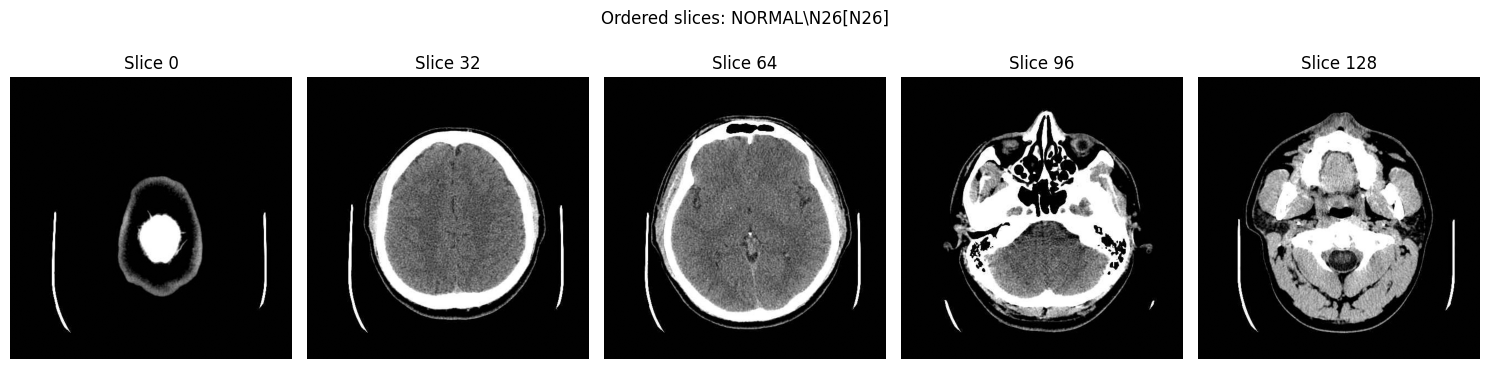

In [8]:
selected_indices = np.linspace(
    0,
    len(ordered_slices) - 1,
    num=5,
    dtype=int,
)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for axis, index in zip(axes, selected_indices):
    image = Image.open(ordered_slices[index]).convert("L")

    axis.imshow(image, cmap="gray")
    axis.set_title(f"Slice {index}")
    axis.axis("off")

plt.suptitle(f"Ordered slices: {example_scan['scan_id']}")
plt.tight_layout()
plt.show()

In [9]:
SEQUENCE_LENGTH = 16

for split_name, scans in [
    ("Train", train_scans),
    ("Validation", val_scans),
    ("Test", test_scans),
]:
    supported_scans = (scans["slice_count"] >= SEQUENCE_LENGTH).sum()

    print(
        f"{split_name}: {supported_scans}/{len(scans)} scans support "
        f"{SEQUENCE_LENGTH} slices"
    )

Train: 28/28 scans support 16 slices
Validation: 7/7 scans support 16 slices
Test: 9/9 scans support 16 slices


In [10]:
IMAGE_SIZE = 128

sequence_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

In [11]:
def select_evenly_spaced_slices(slice_paths, sequence_length):
    indices = np.linspace(
        0,
        len(slice_paths) - 1,
        num=sequence_length,
        dtype=int,
    )
    return [slice_paths[index] for index in indices]


class CTSequenceDataset(Dataset):
    def __init__(self, scans_df, transform, sequence_length):
        self.scans_df = scans_df.reset_index(drop=True)
        self.transform = transform
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.scans_df)

    def __getitem__(self, index):
        scan = self.scans_df.iloc[index]

        ordered_paths = get_ordered_slice_paths(scan["scan_id"])
        selected_paths = select_evenly_spaced_slices(
            ordered_paths,
            self.sequence_length,
        )

        slices = []
        for path in selected_paths:
            image = Image.open(path).convert("RGB")
            slices.append(self.transform(image))

        sequence = torch.stack(slices)  # [16, 1, 128, 128]
        label = torch.tensor(scan["label"], dtype=torch.long)

        return sequence, label

In [12]:
BATCH_SIZE = 2

train_dataset = CTSequenceDataset(
    train_scans,
    transform=sequence_transform,
    sequence_length=SEQUENCE_LENGTH,
)

val_dataset = CTSequenceDataset(
    val_scans,
    transform=sequence_transform,
    sequence_length=SEQUENCE_LENGTH,
)

test_dataset = CTSequenceDataset(
    test_scans,
    transform=sequence_transform,
    sequence_length=SEQUENCE_LENGTH,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(f"Training scans: {len(train_dataset)}")
print(f"Validation scans: {len(val_dataset)}")
print(f"Test scans: {len(test_dataset)}")

Training scans: 28
Validation scans: 7
Test scans: 9


In [13]:
sequences, labels = next(iter(train_loader))

print("Sequence batch shape:", sequences.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels.tolist())
print("Pixel range:", sequences.min().item(), "to", sequences.max().item())

Sequence batch shape: torch.Size([2, 16, 1, 128, 128])
Label batch shape: torch.Size([2])
Labels: [0, 0]
Pixel range: -1.0 to 1.0


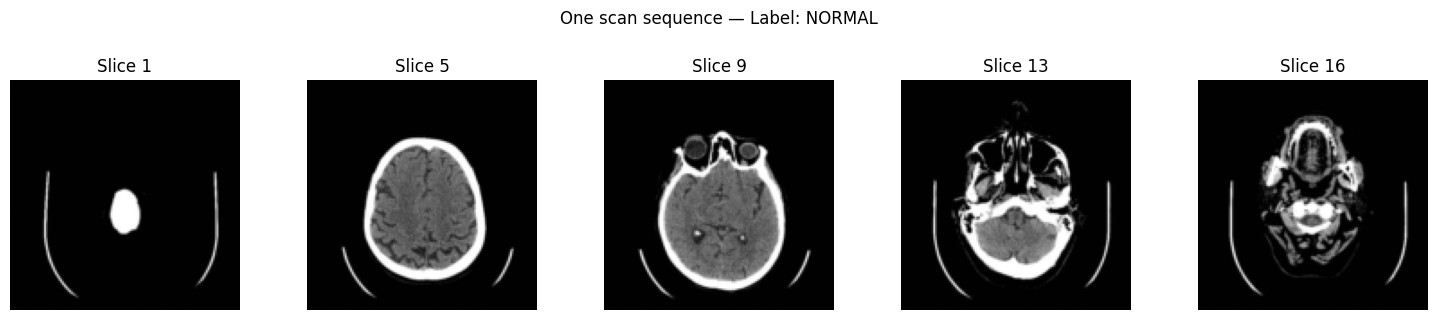

In [14]:
sequence = sequences[0]  # first scan in the current batch
label = labels[0].item()

slice_indices = [0, 4, 8, 12, 15]

fig, axes = plt.subplots(1, len(slice_indices), figsize=(15, 3))

for ax, slice_index in zip(axes, slice_indices):
    image = sequence[slice_index, 0].numpy()

    # Undo normalization only for display
    image = (image * 0.5) + 0.5

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Slice {slice_index + 1}")
    ax.axis("off")

scan_class = "Hemorrhagic" if label == 1 else "NORMAL"
fig.suptitle(f"One scan sequence — Label: {scan_class}", y=1.05)
plt.tight_layout()
plt.show()

In [15]:
class CNNLSTM(nn.Module):
    def __init__(self, feature_size=128, hidden_size=128, num_classes=2):
        super().__init__()

        # CNN: learns features from each individual CT slice
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, feature_size),
            nn.ReLU(),
        )

        # LSTM: learns the relationship across the ordered slices
        self.lstm = nn.LSTM(
            input_size=feature_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, x):
        # Input: [batch, slices, channels, height, width]
        batch_size, sequence_length, channels, height, width = x.shape

        # Send every slice through the CNN
        x = x.view(batch_size * sequence_length, channels, height, width)
        features = self.cnn(x)

        # Restore sequence structure for the LSTM
        features = features.view(batch_size, sequence_length, -1)

        # Use the final LSTM output to classify the complete scan
        lstm_output, _ = self.lstm(features)
        final_output = lstm_output[:, -1, :]

        return self.classifier(final_output)

In [16]:
model = CNNLSTM().to(device)

total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

model.eval()

with torch.no_grad():
    sample_logits = model(sequences.to(device))

print("Input shape:", sequences.shape)
print("Output logits shape:", sample_logits.shape)
print("Sample logits:", sample_logits.cpu())

Total parameters: 164,194
Trainable parameters: 164,194
Input shape: torch.Size([2, 16, 1, 128, 128])
Output logits shape: torch.Size([2, 2])
Sample logits: tensor([[-0.0460,  0.0305],
        [-0.0454,  0.0304]])


In [17]:
class_counts = train_scans["label"].value_counts().sort_index()

class_weights = torch.tensor(
    len(train_scans) / (2 * class_counts.values),
    dtype=torch.float32,
).to(device)

print("Training scans per class:")
print(class_counts)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

Training scans per class:
label
0    17
1    11
Name: count, dtype: int64
Class weights: tensor([0.8235, 1.2727])


In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct_predictions = 0
    total_scans = 0

    for sequences, labels in loader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(sequences)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        predictions = logits.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_scans += labels.size(0)

    average_loss = total_loss / total_scans
    accuracy = correct_predictions / total_scans

    return average_loss, accuracy

In [19]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_scans = 0

    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for sequences, labels in loader:
            sequences = sequences.to(device)
            labels = labels.to(device)

            logits = model(sequences)
            loss = criterion(logits, labels)

            probabilities = torch.softmax(logits, dim=1)[:, 1]
            predictions = logits.argmax(dim=1)

            total_loss += loss.item() * labels.size(0)
            correct_predictions += (predictions == labels).sum().item()
            total_scans += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    average_loss = total_loss / total_scans
    accuracy = correct_predictions / total_scans
    auc = roc_auc_score(all_labels, all_probabilities)

    return average_loss, accuracy, auc, all_labels, all_probabilities

In [20]:
NUM_EPOCHS = 10

MODELS_DIR = PROJECT_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

checkpoint_path = MODELS_DIR / "cnn_lstm_best.pt"

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_auc": [],
}

best_val_auc = float("-inf")
best_epoch = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
    )

    val_loss, val_accuracy, val_auc, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device,
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["val_auc"].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_epoch": best_epoch,
                "best_val_auc": best_val_auc,
                "sequence_length": SEQUENCE_LENGTH,
                "image_size": IMAGE_SIZE,
            },
            checkpoint_path,
        )

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_accuracy:.4f} | "
        f"Val AUC: {val_auc:.4f}"
    )

print(f"\nBest validation AUC: {best_val_auc:.4f} (Epoch {best_epoch})")
print(f"Saved best model to: {checkpoint_path}")

Epoch 01/10 | Train loss: 0.7002 | Train acc: 0.6071 | Val loss: 0.6934 | Val acc: 0.5714 | Val AUC: 0.3333
Epoch 02/10 | Train loss: 0.6875 | Train acc: 0.6071 | Val loss: 0.6959 | Val acc: 0.5714 | Val AUC: 0.2500
Epoch 03/10 | Train loss: 0.6959 | Train acc: 0.5714 | Val loss: 0.6995 | Val acc: 0.5714 | Val AUC: 0.2500
Epoch 04/10 | Train loss: 0.6910 | Train acc: 0.5714 | Val loss: 0.7016 | Val acc: 0.5714 | Val AUC: 0.2500
Epoch 05/10 | Train loss: 0.6832 | Train acc: 0.5714 | Val loss: 0.7085 | Val acc: 0.5714 | Val AUC: 0.0833
Epoch 06/10 | Train loss: 0.6804 | Train acc: 0.5714 | Val loss: 0.7082 | Val acc: 0.5714 | Val AUC: 0.0833
Epoch 07/10 | Train loss: 0.6751 | Train acc: 0.6429 | Val loss: 0.7214 | Val acc: 0.5714 | Val AUC: 0.0833
Epoch 08/10 | Train loss: 0.6766 | Train acc: 0.6786 | Val loss: 0.7333 | Val acc: 0.5714 | Val AUC: 0.1667
Epoch 09/10 | Train loss: 0.6953 | Train acc: 0.5714 | Val loss: 0.7723 | Val acc: 0.5714 | Val AUC: 0.3333
Epoch 10/10 | Train loss: 0.

In [21]:
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


class SequenceAugment:
    def __init__(
        self,
        max_rotation=7,
        max_translation=0.03,
        scale_range=(0.97, 1.03),
    ):
        self.max_rotation = max_rotation
        self.max_translation = max_translation
        self.scale_range = scale_range

    def __call__(self, sequence):
        # sequence shape: [slices, channels, height, width]
        height, width = sequence.shape[-2:]

        angle = random.uniform(-self.max_rotation, self.max_rotation)
        translate_x = int(random.uniform(
            -self.max_translation,
            self.max_translation,
        ) * width)
        translate_y = int(random.uniform(
            -self.max_translation,
            self.max_translation,
        ) * height)
        scale = random.uniform(*self.scale_range)

        # One identical transform is applied across all 16 slices.
        return TF.affine(
            sequence,
            angle=angle,
            translate=[translate_x, translate_y],
            scale=scale,
            shear=[0.0, 0.0],
            interpolation=InterpolationMode.BILINEAR,
            fill=0.0,
        )


train_sequence_augment = SequenceAugment()

In [22]:
class AugmentedCTSequenceDataset(CTSequenceDataset):
    def __init__(
        self,
        scans_df,
        transform,
        sequence_length,
        sequence_augment=None,
    ):
        super().__init__(scans_df, transform, sequence_length)
        self.sequence_augment = sequence_augment

    def __getitem__(self, index):
        sequence, label = super().__getitem__(index)

        if self.sequence_augment is not None:
            sequence = self.sequence_augment(sequence)

        return sequence, label

In [23]:
train_dataset = AugmentedCTSequenceDataset(
    train_scans,
    transform=sequence_transform,
    sequence_length=SEQUENCE_LENGTH,
    sequence_augment=train_sequence_augment,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

print(f"Augmented training scans: {len(train_dataset)}")
print(f"Validation scans unchanged: {len(val_dataset)}")
print(f"Test scans unchanged: {len(test_dataset)}")

Augmented training scans: 28
Validation scans unchanged: 7
Test scans unchanged: 9


In [24]:
augmented_sequence, augmented_label = train_dataset[0]

print("Augmented sequence shape:", augmented_sequence.shape)
print("Label:", augmented_label.item())
print(
    "Pixel range:",
    augmented_sequence.min().item(),
    "to",
    augmented_sequence.max().item(),
)

Augmented sequence shape: torch.Size([16, 1, 128, 128])
Label: 0
Pixel range: -0.9995362758636475 to 1.0


In [25]:
# Start a new experiment from random initial weights
model = CNNLSTM().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4,
)

checkpoint_path = MODELS_DIR / "cnn_lstm_augmented_best.pt"

print("New CNN–LSTM created")
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Checkpoint path:", checkpoint_path)

New CNN–LSTM created
Learning rate: 0.0003
Checkpoint path: e:\vscode\Vision model practice\models\cnn_lstm_augmented_best.pt


In [26]:
MAX_EPOCHS = 20
PATIENCE = 5

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_auc": [],
}

best_val_auc = float("-inf")
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_accuracy, val_auc, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["val_auc"].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_epoch": best_epoch,
                "best_val_auc": best_val_auc,
                "sequence_length": SEQUENCE_LENGTH,
                "image_size": IMAGE_SIZE,
            },
            checkpoint_path,
        )
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_accuracy:.4f} | "
        f"Val AUC: {val_auc:.4f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nBest validation AUC: {best_val_auc:.4f} (Epoch {best_epoch})")
print(f"Saved best model to: {checkpoint_path}")

Epoch 01/20 | Train loss: 0.7048 | Train acc: 0.3571 | Val loss: 0.6945 | Val acc: 0.4286 | Val AUC: 0.4167
Epoch 02/20 | Train loss: 0.6966 | Train acc: 0.3929 | Val loss: 0.6940 | Val acc: 0.4286 | Val AUC: 0.2500
Epoch 03/20 | Train loss: 0.6758 | Train acc: 0.6429 | Val loss: 0.6983 | Val acc: 0.5714 | Val AUC: 0.2500
Epoch 04/20 | Train loss: 0.7023 | Train acc: 0.5000 | Val loss: 0.7030 | Val acc: 0.5714 | Val AUC: 0.1667
Epoch 05/20 | Train loss: 0.6731 | Train acc: 0.6429 | Val loss: 0.7173 | Val acc: 0.5714 | Val AUC: 0.1667
Epoch 06/20 | Train loss: 0.6593 | Train acc: 0.6071 | Val loss: 0.7183 | Val acc: 0.5714 | Val AUC: 0.0833

Early stopping at epoch 6.

Best validation AUC: 0.4167 (Epoch 1)
Saved best model to: e:\vscode\Vision model practice\models\cnn_lstm_augmented_best.pt
